# Experiment 9 — Zipfian primitive frequencies with a Standard SAELens SAE

This standalone notebook implements only Experiments **9A–9C**:

- **9A — Distribution validation:** verify that the generator produces the intended
  truncated Zipf primitive probabilities and independent pair probabilities.
- **9B — Zipf-exponent sweep:** at fixed `N=256`, vary only the frequency exponent
  `alpha` and measure true-primitive recovery.
- **9C — Factorial-sparsity sweep:** fix `alpha=1` and vary `N` to measure how the
  long-tailed distribution interacts with the number of possible compositions.

Experiments 9B and 9C use SAELens `StandardTrainingSAE` with the project-standard
ReLU/L1 architecture. The primary metrics are one-to-one Hungarian recovery at
cosine `>= 0.90` and Mean Max Cosine Similarity (MMCS). Recovery is also saved for
every primitive so results can be analyzed by Zipf rank and expected exposure.

`QUICK_MODE=True` uses small smoke-test budgets and a separate artifact namespace.
Full mode uses 125,000,000 training samples per SAE, five SAE seeds, learning rate
`4e-4`, and L1 coefficient `0.1`, matching the optimized Standard SAE configuration
used by the preceding composed-feature experiments.

## Environment setup

This cell works from either the repository root, the `composed-features` directory,
or Google Colab. Colab clones the repository if it is absent and installs the local
requirements. It does not depend on variables or outputs from any earlier notebook.

In [1]:
import subprocess
import sys
from pathlib import Path


IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    repository_root = Path("/content/SAE")
    if not repository_root.is_dir():
        subprocess.run(
            [
                "git",
                "clone",
                "https://github.com/Adefioye/SAE.git",
                str(repository_root),
            ],
            check=True,
        )
    EXPERIMENT_DIR = repository_root / "composed-features"
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            str(EXPERIMENT_DIR / "requirements.txt"),
        ],
        check=True,
    )
else:
    working_dir = Path.cwd().resolve()
    if (working_dir / "sparse_factorial_generator.py").is_file():
        EXPERIMENT_DIR = working_dir
    elif (
        working_dir / "composed-features" / "sparse_factorial_generator.py"
    ).is_file():
        EXPERIMENT_DIR = working_dir / "composed-features"
    else:
        raise FileNotFoundError(
            "Run this notebook from the repository root or composed-features directory."
        )

EXPERIMENT_DIR = EXPERIMENT_DIR.resolve()
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

print("Experiment directory:", EXPERIMENT_DIR)

Experiment directory: /content/SAE/composed-features


## Imports and experimental contract

Set the three `RUN_9*` flags explicitly. Experiment 9A is inexpensive and enabled
by default. The SAE experiments are disabled by default because full mode is a
multi-billion-sample study. Results and checkpoints are saved after every run and
reused only when their complete specifications match.

In [2]:
import gc
import json
import math
import platform
from collections.abc import Iterator, Sequence
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from scipy.optimize import linear_sum_assignment
from tqdm.auto import tqdm

import sae_lens
from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from sparse_factorial_generator import FactorialConfig, SparseFactorialGenerator
from toy_model import default_device


DEVICE = default_device()

QUICK_MODE = True
RUN_9A = True
RUN_9B = False
RUN_9C = False

LEARNING_RATE = 4e-4
L1_COEFFICIENT = 0.1
ZIPF_SHIFT = 0.0
DICTIONARY_SEED = 0
DATA_SEED = 0
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999

if QUICK_MODE:
    TRAINING_SAMPLES = 131_072
    TRAIN_BATCH_SIZE = 4_096
    VALIDATION_SAMPLES = 100_000
    SAE_SEEDS = (0,)
    ALPHAS_9B = (0.0, 1.0)
    N_9B = 32
    N_VALUES_9C = (8, 32)
    N_VALUES_9A = (8, 32)
else:
    TRAINING_SAMPLES = 125_000_000
    TRAIN_BATCH_SIZE = 16_384
    VALIDATION_SAMPLES = 2_000_000
    SAE_SEEDS = tuple(range(5))
    ALPHAS_9B = (0.0, 0.5, 1.0, 1.5)
    N_9B = 256
    N_VALUES_9C = (8, 32, 128, 256)
    N_VALUES_9A = (8, 256)

ALPHAS_9A = ALPHAS_9B
ALPHA_9C = 1.0

MODE_NAMESPACE = "quick" if QUICK_MODE else "full_125m"
ARTIFACT_ROOT = (
    EXPERIMENT_DIR
    / "artifacts"
    / "09_zipfian_feature_frequencies"
    / MODE_NAMESPACE
)
CHECKPOINT_ROOT = ARTIFACT_ROOT / "sae_checkpoints"
RESULTS_ROOT = ARTIFACT_ROOT / "results"
for directory in (CHECKPOINT_ROOT, RESULTS_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

RUN_CONFIG = {
    "study": "09_zipfian_feature_frequencies",
    "quick_mode": QUICK_MODE,
    "training_samples_per_sae": TRAINING_SAMPLES,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "validation_samples": VALIDATION_SAMPLES,
    "sae_seeds": list(SAE_SEEDS),
    "alphas_9b": list(ALPHAS_9B),
    "n_9b": N_9B,
    "alpha_9c": ALPHA_9C,
    "n_values_9c": list(N_VALUES_9C),
    "learning_rate": LEARNING_RATE,
    "l1_coefficient": L1_COEFFICIENT,
    "zipf_shift": ZIPF_SHIFT,
    "dictionary_seed": DICTIONARY_SEED,
    "data_seed": DATA_SEED,
    "sae_lens_version": sae_lens.__version__,
    "torch_version": torch.__version__,
    "python_version": platform.python_version(),
}
(RESULTS_ROOT / "run_config.json").write_text(
    json.dumps(RUN_CONFIG, indent=2) + "\n"
)

print("Device:", DEVICE)
print("SAELens:", sae_lens.__version__)
print("Mode:", MODE_NAMESPACE)
print("Samples per SAE:", f"{TRAINING_SAMPLES:,}")
print("SAE seeds:", SAE_SEEDS)
print("Artifact root:", ARTIFACT_ROOT)

Device: cuda
SAELens: 6.47.0
Mode: quick
Samples per SAE: 131,072
SAE seeds: (0,)
Artifact root: /content/SAE/composed-features/artifacts/09_zipfian_feature_frequencies/quick


## Dictionary, generator, and Standard SAE helpers

There are `N` primitives in each of the `x` and `y` sets and `2N` SAE latents.
The two sets occupy orthogonal subspaces. Within each set, consecutive primitive
rows form antipodal pairs, preserving the geometry of Experiment 3.

In [3]:
def orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device="cpu").manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int,
    *,
    seed: int,
    device: torch.device | str,
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError("Antipodal geometry requires a positive, even N.")
    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0
        y_offset = n_per_set
        y_axis = half + axis
        dictionary[y_offset + 2 * axis, y_axis] = 1.0
        dictionary[y_offset + 2 * axis + 1, y_axis] = -1.0
    return (dictionary @ orthogonal_matrix(n_per_set, seed)).to(device)


@dataclass(frozen=True)
class ExperimentSpec:
    study: str
    n_per_set: int
    alpha: float
    sae_seed: int
    dictionary_seed: int = DICTIONARY_SEED
    data_seed: int = DATA_SEED
    training_samples: int = TRAINING_SAMPLES
    batch_size: int = TRAIN_BATCH_SIZE
    learning_rate: float = LEARNING_RATE
    l1_coefficient: float = L1_COEFFICIENT
    zipf_shift: float = ZIPF_SHIFT

    @property
    def activation_dim(self) -> int:
        return self.n_per_set

    @property
    def d_sae(self) -> int:
        return 2 * self.n_per_set

    @property
    def index_distribution(self) -> str:
        return "uniform" if self.alpha == 0 else "zipf"

    def checkpoint_slug(self) -> str:
        alpha_slug = format(self.alpha, ".8g").replace(".", "p")
        return (
            f"N-{self.n_per_set:04d}__alpha-{alpha_slug}"
            f"__dict-{self.dictionary_seed}__data-{self.data_seed}"
            f"__sae-{self.sae_seed}__T-{self.training_samples}"
            f"__batch-{self.batch_size}"
        )


def build_dictionary(spec: ExperimentSpec) -> torch.Tensor:
    return make_antipodal_dictionary(
        spec.n_per_set,
        seed=spec.dictionary_seed,
        device=DEVICE,
    )


def build_generator(
    spec: ExperimentSpec,
    *,
    seed: int | None = None,
) -> SparseFactorialGenerator:
    return SparseFactorialGenerator(
        FactorialConfig(
            n_x=spec.n_per_set,
            n_y=spec.n_per_set,
            activation_dim=spec.activation_dim,
            amplitude_correlation=1.0,
            singleton_probability=0.0,
            noise_std=0.0,
            seed=spec.data_seed if seed is None else seed,
            index_distribution=spec.index_distribution,
            zipf_exponent=spec.alpha,
            zipf_shift=spec.zipf_shift,
        ),
        device=str(DEVICE),
        true_dictionary=build_dictionary(spec),
        normalize_dictionary=False,
    )


class FixedBatchActivationIterator(Iterator[torch.Tensor]):
    def __init__(
        self,
        generator: SparseFactorialGenerator,
        batch_size: int,
    ) -> None:
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    @torch.no_grad()
    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


def make_standard_sae(spec: ExperimentSpec) -> StandardTrainingSAE:
    torch.manual_seed(spec.sae_seed)
    cfg = StandardTrainingSAEConfig(
        d_in=spec.activation_dim,
        d_sae=spec.d_sae,
        device=str(DEVICE),
        dtype="float32",
        apply_b_dec_to_input=False,
        normalize_activations="none",
        l1_coefficient=spec.l1_coefficient,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(cfg).to(DEVICE)


def make_trainer(
    spec: ExperimentSpec,
    sae: StandardTrainingSAE,
    generator: SparseFactorialGenerator,
) -> SAETrainer:
    cfg = SAETrainerConfig(
        total_training_samples=spec.training_samples,
        train_batch_size_samples=spec.batch_size,
        lr=spec.learning_rate,
        lr_end=spec.learning_rate,
        lr_scheduler_name="constant",
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False,
            eval_every_n_wandb_logs=2**31 - 1,
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=cfg,
        sae=sae,
        data_provider=FixedBatchActivationIterator(generator, spec.batch_size),
    )


def train_exact_sample_budget(
    spec: ExperimentSpec,
    trainer: SAETrainer,
    generator: SparseFactorialGenerator,
) -> StandardTrainingSAE:
    progress = tqdm(
        total=spec.training_samples,
        initial=trainer.n_training_samples,
        desc=(
            f"{spec.study}: N={spec.n_per_set}, alpha={spec.alpha:g}, "
            f"seed={spec.sae_seed}"
        ),
    )
    while trainer.n_training_samples < spec.training_samples:
        remaining = spec.training_samples - trainer.n_training_samples
        current_batch_size = min(spec.batch_size, remaining)
        hidden, _ = generator.sample(current_batch_size)
        trainer.maybe_reset_sparsity()
        step_output = trainer.step(hidden.detach())
        if not bool(torch.isfinite(step_output.loss).all()):
            progress.close()
            raise FloatingPointError(
                f"Non-finite loss at step {trainer.n_training_steps:,}."
            )
        trainer.n_training_steps += 1
        progress.update(current_batch_size)
    trainer.set_final_sae_metadata()
    progress.close()
    return trainer.sae


def checkpoint_spec(spec: ExperimentSpec) -> dict:
    training_spec = asdict(spec)
    # The study label is organizational, not part of the trained model identity.
    # Omitting it lets the identical N=256, alpha=1 run be shared by 9B and 9C.
    training_spec.pop("study")
    return {
        **training_spec,
        "index_distribution": spec.index_distribution,
        "activation_dim": spec.activation_dim,
        "d_sae": spec.d_sae,
        "architecture": "StandardTrainingSAE",
        "apply_b_dec_to_input": False,
        "normalize_activations": "none",
        "lp_norm": 1.0,
        "l1_warm_up_steps": 0,
        "decoder_init_norm": 1.0,
        "adam_beta1": ADAM_BETA1,
        "adam_beta2": ADAM_BETA2,
        "sae_lens_version": sae_lens.__version__,
    }


def checkpoint_matches(path: Path, expected: dict) -> bool:
    required = ("cfg.json", "sae_weights.safetensors", "experiment_spec.json")
    if not all((path / filename).is_file() for filename in required):
        return False
    try:
        saved = json.loads((path / "experiment_spec.json").read_text())
    except (OSError, json.JSONDecodeError):
        return False
    return all(saved.get(key) == value for key, value in expected.items())


def train_or_load_sae(
    spec: ExperimentSpec,
) -> tuple[StandardTrainingSAE, str, int]:
    path = CHECKPOINT_ROOT / spec.checkpoint_slug()
    expected = checkpoint_spec(spec)
    expected_steps = math.ceil(spec.training_samples / spec.batch_size)
    if checkpoint_matches(path, expected):
        sae = StandardTrainingSAE.load_from_disk(
            path,
            device=str(DEVICE),
            dtype="float32",
        ).to(DEVICE)
        return sae, "loaded_checkpoint", expected_steps
    if path.exists():
        raise ValueError(f"Checkpoint exists but does not match this run: {path}")

    generator = build_generator(spec)
    sae = make_standard_sae(spec)
    trainer = make_trainer(spec, sae, generator)
    sae = train_exact_sample_budget(spec, trainer, generator)
    path.mkdir(parents=True, exist_ok=False)
    sae.save_model(path)
    expected["device_used_to_train"] = str(DEVICE)
    (path / "experiment_spec.json").write_text(
        json.dumps(expected, indent=2) + "\n"
    )
    return sae, "new_training_run", trainer.n_training_steps


def clear_accelerator_cache() -> None:
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()

## Recovery, persistence, and plotting helpers

For normalized true primitives `D` and decoder rows `W_dec`, the signed cosine
matrix is `S = D @ W_dec.T`. MMCS averages each primitive's best decoder cosine.
Hungarian 90% first maximizes total signed cosine under a one-to-one assignment and
then reports the fraction of assigned cosines at least `0.90`. Signed cosine is
intentional because the antipodal directions are distinct ground-truth primitives.

In [4]:
@torch.no_grad()
def primitive_recovery(
    spec: ExperimentSpec,
    sae: StandardTrainingSAE,
    dictionary: torch.Tensor,
) -> tuple[dict[str, float], pd.DataFrame]:
    decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitives = F.normalize(dictionary.detach().float(), dim=1)
    similarity = primitives @ decoder.T

    maximum_cosines = similarity.max(dim=1).values
    primitive_rows, decoder_cols = linear_sum_assignment(
        (-similarity).detach().cpu().numpy()
    )
    assigned_by_primitive = torch.full(
        (2 * spec.n_per_set,),
        float("nan"),
        device=similarity.device,
    )
    row_tensor = torch.as_tensor(primitive_rows, device=similarity.device)
    column_tensor = torch.as_tensor(decoder_cols, device=similarity.device)
    assigned_by_primitive[row_tensor] = similarity[row_tensor, column_tensor]

    probability_generator = build_generator(spec, seed=spec.data_seed + 10_000)
    probabilities = torch.cat(
        [
            probability_generator.x_probabilities,
            probability_generator.y_probabilities,
        ]
    )
    groups = ["x"] * spec.n_per_set + ["y"] * spec.n_per_set
    ranks = list(range(1, spec.n_per_set + 1)) * 2

    details = pd.DataFrame(
        {
            "study": spec.study,
            "n_per_set": spec.n_per_set,
            "alpha": spec.alpha,
            "sae_seed": spec.sae_seed,
            "primitive_index": list(range(2 * spec.n_per_set)),
            "primitive_group": groups,
            "rank": ranks,
            "probability": probabilities.detach().cpu().numpy(),
            "expected_exposure": (
                spec.training_samples * probabilities
            ).detach().cpu().numpy(),
            "max_cosine": maximum_cosines.detach().cpu().numpy(),
            "assigned_cosine": assigned_by_primitive.detach().cpu().numpy(),
        }
    )
    details["recovered_90"] = details["assigned_cosine"] >= 0.90

    top_pair = F.normalize(
        primitives[0] + primitives[spec.n_per_set],
        dim=0,
    )
    metrics = {
        "hungarian_90": float(details["recovered_90"].mean()),
        "mmcs": float(maximum_cosines.mean()),
        "assigned_cosine_mean": float(assigned_by_primitive.mean()),
        "top_pair_max_cosine": float((top_pair @ decoder.T).max()),
    }
    return metrics, details


SUMMARY_COLUMNS = [
    "study",
    "n_per_set",
    "alpha",
    "index_distribution",
    "sae_seed",
    "dictionary_seed",
    "data_seed",
    "training_samples",
    "train_batch_size",
    "optimizer_steps",
    "learning_rate",
    "l1_coefficient",
    "checkpoint_source",
    "hungarian_90",
    "mmcs",
    "assigned_cosine_mean",
    "top_pair_max_cosine",
]


def atomic_to_csv(frame: pd.DataFrame, path: Path) -> None:
    temporary_path = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temporary_path, index=False)
    temporary_path.replace(path)


def spec_key(spec: ExperimentSpec) -> tuple[int, float, int]:
    return spec.n_per_set, spec.alpha, spec.sae_seed


def row_key(row: dict) -> tuple[int, float, int]:
    return int(row["n_per_set"]), float(row["alpha"]), int(row["sae_seed"])


def run_study(
    specs: Sequence[ExperimentSpec],
    *,
    summary_path: Path,
    detail_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    completed: dict[tuple[int, float, int], dict] = {}
    detail_frames: dict[tuple[int, float, int], pd.DataFrame] = {}
    if summary_path.is_file():
        saved_summary = pd.read_csv(summary_path)
        missing = set(SUMMARY_COLUMNS).difference(saved_summary.columns)
        if missing:
            raise ValueError(f"{summary_path} is missing columns: {sorted(missing)}")
        completed = {
            row_key(row): row
            for row in saved_summary[SUMMARY_COLUMNS].to_dict(orient="records")
        }
    if detail_path.is_file():
        saved_details = pd.read_csv(detail_path)
        for key_values, group in saved_details.groupby(
            ["n_per_set", "alpha", "sae_seed"],
            sort=False,
        ):
            key = (int(key_values[0]), float(key_values[1]), int(key_values[2]))
            detail_frames[key] = group.copy()

    expected_keys = [spec_key(spec) for spec in specs]
    unexpected = set(completed).difference(expected_keys)
    if unexpected:
        raise ValueError(f"Unexpected saved result keys: {sorted(unexpected)}")

    for run_index, spec in enumerate(specs, start=1):
        key = spec_key(spec)
        if key in completed and key in detail_frames:
            print(f"[{run_index}/{len(specs)}] Reused result: {key}")
            continue
        sae, checkpoint_source, optimizer_steps = train_or_load_sae(spec)
        metrics, details = primitive_recovery(spec, sae, build_dictionary(spec))
        completed[key] = {
            "study": spec.study,
            "n_per_set": spec.n_per_set,
            "alpha": spec.alpha,
            "index_distribution": spec.index_distribution,
            "sae_seed": spec.sae_seed,
            "dictionary_seed": spec.dictionary_seed,
            "data_seed": spec.data_seed,
            "training_samples": spec.training_samples,
            "train_batch_size": spec.batch_size,
            "optimizer_steps": optimizer_steps,
            "learning_rate": spec.learning_rate,
            "l1_coefficient": spec.l1_coefficient,
            "checkpoint_source": checkpoint_source,
            **metrics,
        }
        detail_frames[key] = details

        ordered_summary = pd.DataFrame(
            [completed[item] for item in expected_keys if item in completed]
        )[SUMMARY_COLUMNS]
        ordered_details = pd.concat(
            [detail_frames[item] for item in expected_keys if item in detail_frames],
            ignore_index=True,
        )
        atomic_to_csv(ordered_summary, summary_path)
        atomic_to_csv(ordered_details, detail_path)
        print(
            f"Saved {key}: H90={metrics['hungarian_90']:.4f}, "
            f"MMCS={metrics['mmcs']:.6f}"
        )
        del sae
        clear_accelerator_cache()

    missing_keys = [key for key in expected_keys if key not in completed]
    if missing_keys:
        raise RuntimeError(f"Missing study runs: {missing_keys}")
    return (
        pd.DataFrame([completed[key] for key in expected_keys])[SUMMARY_COLUMNS],
        pd.concat([detail_frames[key] for key in expected_keys], ignore_index=True),
    )


def aggregate_metrics(
    frame: pd.DataFrame,
    group_column: str,
) -> pd.DataFrame:
    records = []
    for group_value, group in frame.groupby(group_column, sort=True):
        record = {group_column: group_value, "n_sae_seeds": len(group)}
        for metric in (
            "hungarian_90",
            "mmcs",
            "assigned_cosine_mean",
            "top_pair_max_cosine",
        ):
            values = group[metric].astype(float)
            record[f"{metric}_mean"] = float(values.mean())
            record[f"{metric}_std"] = float(values.std(ddof=0))
        records.append(record)
    return pd.DataFrame(records)


def plot_two_recovery_metrics(
    aggregate: pd.DataFrame,
    *,
    x_column: str,
    xlabel: str,
    output_path: Path,
    log2_x: bool = False,
) -> None:
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for axis, metric, title in (
        (axes[0], "hungarian_90", "Hungarian recovery at cosine >= 0.90"),
        (axes[1], "mmcs", "Mean Max Cosine Similarity"),
    ):
        axis.errorbar(
            aggregate[x_column],
            aggregate[f"{metric}_mean"],
            yerr=aggregate[f"{metric}_std"],
            marker="o",
            linewidth=2,
            capsize=4,
        )
        axis.set(xlabel=xlabel, ylabel=metric, title=title, ylim=(-0.05, 1.05))
        if log2_x:
            axis.set_xscale("log", base=2)
            axis.set_xticks(aggregate[x_column])
            axis.set_xticklabels([str(int(value)) for value in aggregate[x_column]])
        axis.grid(alpha=0.25)
    figure.savefig(output_path, dpi=200, bbox_inches="tight")
    print("Saved plot:", output_path)
    plt.show()

## Experiment 9A — Validate the sampled distribution

Each condition streams validation batches, counts primitive identities and pairs,
and compares them with the exact categorical probabilities. For `alpha=0`, the
notebook uses the generator's original uniform `torch.randint` path. For positive
`alpha`, it uses the truncated Zipf probabilities
`p(r) = r**(-alpha) / sum(k**(-alpha))`.

,n_per_set,alpha,n_samples,max_abs_x_error,max_abs_y_error,max_abs_pair_error
0,8,0.0000000,100000,0.0014900,0.0018100,0.0009850
1,8,1.0000000,100000,0.0032131,0.0018515,0.0014941
2,32,0.0000000,100000,0.0010600,0.0013600,0.0003634
3,32,1.0000000,100000,0.0038633,0.0023084,0.0011787


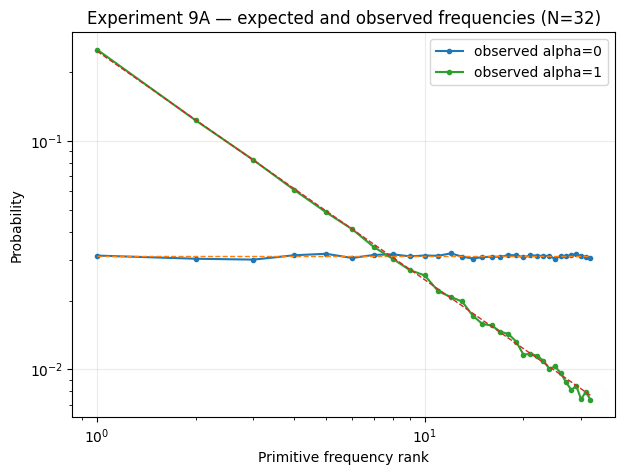

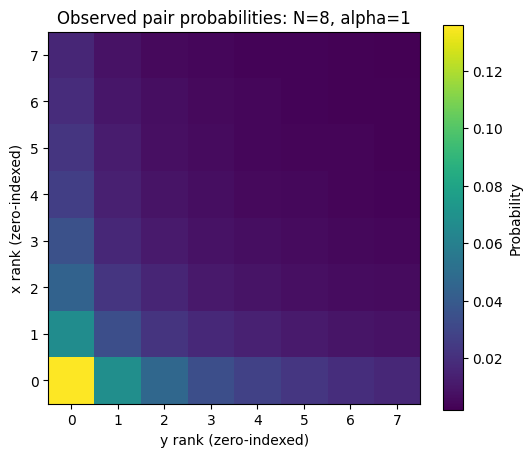

In [5]:
def validate_distribution_condition(
    n_per_set: int,
    alpha: float,
    n_samples: int,
) -> tuple[pd.DataFrame, dict, torch.Tensor]:
    spec = ExperimentSpec(
        study="9A",
        n_per_set=n_per_set,
        alpha=alpha,
        sae_seed=0,
    )
    generator = build_generator(spec, seed=DATA_SEED + 9_000)
    x_counts = torch.zeros(n_per_set, dtype=torch.long, device=DEVICE)
    y_counts = torch.zeros(n_per_set, dtype=torch.long, device=DEVICE)
    pair_counts = torch.zeros(
        n_per_set,
        n_per_set,
        dtype=torch.long,
        device=DEVICE,
    )

    processed = 0
    validation_batch_size = min(TRAIN_BATCH_SIZE, n_samples)
    while processed < n_samples:
        current_batch_size = min(validation_batch_size, n_samples - processed)
        _, coefficients = generator.sample(current_batch_size)
        x_indices = coefficients[:, :n_per_set].argmax(dim=1)
        y_indices = coefficients[:, n_per_set:].argmax(dim=1)
        x_counts += torch.bincount(x_indices, minlength=n_per_set)
        y_counts += torch.bincount(y_indices, minlength=n_per_set)
        flat_pairs = x_indices * n_per_set + y_indices
        pair_counts += torch.bincount(
            flat_pairs,
            minlength=n_per_set * n_per_set,
        ).reshape(n_per_set, n_per_set)
        processed += current_batch_size

    expected = generator.x_probabilities.detach().cpu()
    observed_x = (x_counts / n_samples).detach().cpu()
    observed_y = (y_counts / n_samples).detach().cpu()
    observed_pairs = (pair_counts / n_samples).detach().cpu()
    expected_pairs = torch.outer(expected, expected)

    rank_frame = pd.DataFrame(
        {
            "n_per_set": n_per_set,
            "alpha": alpha,
            "rank": range(1, n_per_set + 1),
            "expected_probability": expected.numpy(),
            "observed_x_probability": observed_x.numpy(),
            "observed_y_probability": observed_y.numpy(),
        }
    )
    summary = {
        "n_per_set": n_per_set,
        "alpha": alpha,
        "n_samples": n_samples,
        "max_abs_x_error": float((observed_x - expected).abs().max()),
        "max_abs_y_error": float((observed_y - expected).abs().max()),
        "max_abs_pair_error": float(
            (observed_pairs - expected_pairs).abs().max()
        ),
    }
    return rank_frame, summary, observed_pairs


if RUN_9A:
    rank_frames = []
    validation_summaries = []
    heatmap_pairs = None
    heatmap_n = min(N_VALUES_9A)
    heatmap_alpha = 1.0 if 1.0 in ALPHAS_9A else max(ALPHAS_9A)
    for n_per_set in N_VALUES_9A:
        for alpha in ALPHAS_9A:
            rank_frame, summary, observed_pairs = validate_distribution_condition(
                n_per_set,
                alpha,
                VALIDATION_SAMPLES,
            )
            rank_frames.append(rank_frame)
            validation_summaries.append(summary)
            if n_per_set == heatmap_n and alpha == heatmap_alpha:
                heatmap_pairs = observed_pairs

    validation_ranks = pd.concat(rank_frames, ignore_index=True)
    validation_summary = pd.DataFrame(validation_summaries)
    atomic_to_csv(validation_ranks, RESULTS_ROOT / "9a_rank_frequencies.csv")
    atomic_to_csv(validation_summary, RESULTS_ROOT / "9a_validation_summary.csv")
    display(validation_summary.style.format(precision=7))

    plot_n = max(N_VALUES_9A)
    figure, axis = plt.subplots(figsize=(7, 5))
    for alpha in ALPHAS_9A:
        subset = validation_ranks[
            (validation_ranks["n_per_set"] == plot_n)
            & (validation_ranks["alpha"] == alpha)
        ]
        axis.plot(
            subset["rank"],
            subset["observed_x_probability"],
            marker=".",
            linewidth=1.5,
            label=f"observed alpha={alpha:g}",
        )
        axis.plot(
            subset["rank"],
            subset["expected_probability"],
            linestyle="--",
            linewidth=1,
        )
    axis.set(
        xscale="log",
        yscale="log",
        xlabel="Primitive frequency rank",
        ylabel="Probability",
        title=f"Experiment 9A — expected and observed frequencies (N={plot_n})",
    )
    axis.grid(alpha=0.25)
    axis.legend()
    frequency_plot_path = RESULTS_ROOT / "9a_rank_frequency_validation.png"
    figure.savefig(frequency_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    if heatmap_pairs is not None:
        figure, axis = plt.subplots(figsize=(6, 5))
        image = axis.imshow(heatmap_pairs.numpy(), origin="lower", cmap="viridis")
        axis.set(
            xlabel="y rank (zero-indexed)",
            ylabel="x rank (zero-indexed)",
            title=(
                f"Observed pair probabilities: N={heatmap_n}, "
                f"alpha={heatmap_alpha:g}"
            ),
        )
        figure.colorbar(image, ax=axis, label="Probability")
        pair_plot_path = RESULTS_ROOT / "9a_pair_probability_heatmap.png"
        figure.savefig(pair_plot_path, dpi=200, bbox_inches="tight")
        plt.show()
else:
    print("Experiment 9A disabled. Set RUN_9A=True to validate the sampler.")

## Experiment 9B — Zipf exponent sweep at fixed N

This experiment changes only `alpha`. `alpha=0` is the uniform control and positive
values progressively concentrate probability in low-rank primitives. Every full
condition uses five independently initialized Standard SAEs and 125M samples.

In [6]:
SPECS_9B = [
    ExperimentSpec(
        study="9B",
        n_per_set=N_9B,
        alpha=alpha,
        sae_seed=sae_seed,
    )
    for alpha in ALPHAS_9B
    for sae_seed in SAE_SEEDS
]
SUMMARY_9B_PATH = RESULTS_ROOT / "9b_per_seed.csv"
DETAIL_9B_PATH = RESULTS_ROOT / "9b_per_primitive.csv"

if RUN_9B:
    results_9b, primitive_results_9b = run_study(
        SPECS_9B,
        summary_path=SUMMARY_9B_PATH,
        detail_path=DETAIL_9B_PATH,
    )
elif SUMMARY_9B_PATH.is_file() and DETAIL_9B_PATH.is_file():
    results_9b = pd.read_csv(SUMMARY_9B_PATH)
    primitive_results_9b = pd.read_csv(DETAIL_9B_PATH)
    print("Loaded saved Experiment 9B results.")
else:
    results_9b = pd.DataFrame()
    primitive_results_9b = pd.DataFrame()
    print("Experiment 9B disabled and no saved results were found.")

if not results_9b.empty:
    aggregate_9b = aggregate_metrics(results_9b, "alpha")
    atomic_to_csv(aggregate_9b, RESULTS_ROOT / "9b_aggregate.csv")
    display(results_9b)
    display(aggregate_9b.style.format(precision=5))
    plot_two_recovery_metrics(
        aggregate_9b,
        x_column="alpha",
        xlabel="Zipf exponent alpha",
        output_path=RESULTS_ROOT / "9b_recovery_by_alpha.png",
    )

    rank_9b = (
        primitive_results_9b.groupby(["alpha", "rank"], as_index=False)
        .agg(
            recovered_90=("recovered_90", "mean"),
            max_cosine=("max_cosine", "mean"),
            assigned_cosine=("assigned_cosine", "mean"),
            expected_exposure=("expected_exposure", "first"),
        )
        .sort_values(["alpha", "rank"])
    )
    atomic_to_csv(rank_9b, RESULTS_ROOT / "9b_recovery_by_rank.csv")
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    for alpha, group in rank_9b.groupby("alpha", sort=True):
        axes[0].plot(
            group["rank"],
            group["recovered_90"],
            label=f"alpha={alpha:g}",
        )
        axes[1].plot(
            group["rank"],
            group["max_cosine"],
            label=f"alpha={alpha:g}",
        )
    for axis, ylabel, title in (
        (axes[0], "Hungarian recovery fraction", "Recovery at cosine >= 0.90"),
        (axes[1], "Mean maximum cosine", "MMCS contribution by rank"),
    ):
        axis.set(
            xscale="log",
            xlabel="Primitive frequency rank",
            ylabel=ylabel,
            title=title,
            ylim=(-0.05, 1.05),
        )
        axis.grid(alpha=0.25)
        axis.legend()
    rank_plot_path = RESULTS_ROOT / "9b_recovery_by_rank.png"
    figure.savefig(rank_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

Experiment 9B disabled and no saved results were found.


## Experiment 9C — Zipfian recovery across N

This experiment fixes `alpha=1` and changes the number of primitives per set. The
number of possible pair compositions grows as `N**2`, while the SAE width remains
exactly the number of true primitives, `2N`. The `N=256, alpha=1` checkpoints are
shared with 9B because checkpoint identity depends on the complete data/model
specification rather than the study label.

In [ ]:
SPECS_9C = [
    ExperimentSpec(
        study="9C",
        n_per_set=n_per_set,
        alpha=ALPHA_9C,
        sae_seed=sae_seed,
    )
    for n_per_set in N_VALUES_9C
    for sae_seed in SAE_SEEDS
]
SUMMARY_9C_PATH = RESULTS_ROOT / "9c_per_seed.csv"
DETAIL_9C_PATH = RESULTS_ROOT / "9c_per_primitive.csv"

if RUN_9C:
    results_9c, primitive_results_9c = run_study(
        SPECS_9C,
        summary_path=SUMMARY_9C_PATH,
        detail_path=DETAIL_9C_PATH,
    )
elif SUMMARY_9C_PATH.is_file() and DETAIL_9C_PATH.is_file():
    results_9c = pd.read_csv(SUMMARY_9C_PATH)
    primitive_results_9c = pd.read_csv(DETAIL_9C_PATH)
    print("Loaded saved Experiment 9C results.")
else:
    results_9c = pd.DataFrame()
    primitive_results_9c = pd.DataFrame()
    print("Experiment 9C disabled and no saved results were found.")

if not results_9c.empty:
    aggregate_9c = aggregate_metrics(results_9c, "n_per_set")
    atomic_to_csv(aggregate_9c, RESULTS_ROOT / "9c_aggregate.csv")
    display(results_9c)
    display(aggregate_9c.style.format(precision=5))
    plot_two_recovery_metrics(
        aggregate_9c,
        x_column="n_per_set",
        xlabel="Number of primitives per set (N)",
        output_path=RESULTS_ROOT / "9c_recovery_by_n.png",
        log2_x=True,
    )

    primitive_results_9c = primitive_results_9c.copy()
    primitive_results_9c["rank_quantile"] = primitive_results_9c.groupby(
        ["n_per_set", "sae_seed", "primitive_group"]
    )["rank"].transform(
        lambda values: pd.qcut(
            values,
            q=min(4, values.nunique()),
            labels=False,
            duplicates="drop",
        )
    )
    quantiles_9c = (
        primitive_results_9c.groupby(
            ["n_per_set", "rank_quantile"],
            as_index=False,
        )
        .agg(
            recovered_90=("recovered_90", "mean"),
            max_cosine=("max_cosine", "mean"),
            expected_exposure=("expected_exposure", "mean"),
        )
        .sort_values(["n_per_set", "rank_quantile"])
    )
    atomic_to_csv(quantiles_9c, RESULTS_ROOT / "9c_recovery_by_rank_quantile.csv")
    display(quantiles_9c.style.format(precision=5))

## Interpretation checklist

1. Confirm 9A's observed probabilities track the intended rank curve and that pair
   errors are small before interpreting any SAE result.
2. In 9B, use macro Hungarian 90% and MMCS as the primary outcomes. Then inspect
   recovery by rank to locate whether any aggregate decline is concentrated in the
   long tail.
3. Compare `top_pair_max_cosine` with primitive recovery. Rising alignment to the
   most common composed direction alongside falling primitive recovery is evidence
   of composition learning rather than generic optimization failure.
4. In 9C, compare both aggregate recovery and rank quantiles across `N`. A fixed
   sample budget changes expected tail exposure, so interpret the saved
   `expected_exposure` column alongside cosine recovery.
5. This notebook intentionally does not implement the antipodal-balanced control or
   tail-exposure-matched training; those are Experiments 9D and 9E and are outside
   the requested 9A–9C scope.